# ELT-PCS Visibility of Nearby Exoplanets

This notebook evaluates the direct-imaging detectability of nearby exoplanets with ELT-PCS using orbital geometry and reflected-light contrast.

## Workflow
1. Define physical assumptions and helper functions.
2. Load the curated catalogue and harmonized Earth-unit columns.
3. Compute maximum angular separation and contrast at that point.
4. Build an interactive diagnostic plot and publication-ready static figure.
5. Run consistency checks for mass, radius, and HZ metadata.

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.express as px
from astropy import constants as const

# =============================================================================
# Acknowledgments and References:
# Some orbital calculation functions and mass-radius conversions are
# inspired by and adapted from the GRIP (Ground-based Reflected Light
# Imaging Planner) project.
# Ref: https://getagrip.streamlit.app/
# =============================================================================

# 1) Input and output files (project-level configuration)
INPUT_CATALOG_FILE = Path('Exoplanets_SolarNeighbourhood_Catalogue.csv')
OUTPUT_INTERACTIVE_HTML = Path('exoplanets_visualization.html')
OUTPUT_PUBLICATION_PNG = Path('exoplanets_publication_figure.png')

# 2) GRIP-inspired constants and default parameters
GEOMETRIC_ALBEDO = 0.3
STATISTICAL_INCLINATION_DEG = 60.0  # in degrees
DEFAULT_OMEGA_DEG = 90.0            # in degrees (argument of periastron)
JUPITER_TO_EARTH_MASS = (const.M_jup / const.M_earth).value
JUPITER_TO_EARTH_RADIUS = (const.R_jup / const.R_earth).value

# ELT/PCS approximate limits (from "A Roadmap for Exoearth Imaging with the ELT")
PCS_IWA_ARCSEC = 0.015
PCS_CONTRAST_LIMIT = 1e-10

# Detectable-limit model (piecewise in log-log space)
DETECT_X_BREAK = 1e-1
DETECT_Y_AT_IWA = 1e-8
DETECT_Y_AT_BREAK = 1e-9

DISTANCE_COLUMN = 'star_distance'

# Category styling for interactive Plotly figures
CATEGORY_STYLE = {
    'Terrestrial': {'color': '#5a3a1b', 'size': 2},
    'Sub-Neptune': {'color': "#378cb1", 'size': 4},
    'Ice Giant': {'color': '#1e3a8a', 'size': 6},
    'Gas Giant': {'color': "#e9982e", 'size': 8},
    'Unknown': {'color': '#495057', 'size': 2},
}

CATEGORY_LABEL = {
    'Terrestrial': 'Terrestrial (<1.6 R⊕)',
    'Sub-Neptune': 'Sub-Neptune (1.6-4 R⊕)',
    'Ice Giant': 'Ice Giant (4-8 R⊕)',
    'Gas Giant': 'Gas Giant (>8 R⊕)',
    'Unknown': 'Unknown',
}

# 3) Helper functions
def to_float(value):
    """Safely converts values to float, including string values with units/symbols."""
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    # Extracts the first valid numeric token from mixed strings (units, symbols).
    text = str(value).strip().replace(',', '.')
    match = re.search(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', text)
    if match:
        return float(match.group(0))

    return np.nan


def get_radius_category_and_style(radius_earth):
    """Returns category key/label and Plotly style from planet radius in Earth units."""
    if pd.isna(radius_earth):
        key = 'Unknown'
    elif radius_earth < 1.6:
        key = 'Terrestrial'
    elif radius_earth < 4.0:
        key = 'Sub-Neptune'
    elif radius_earth < 8.0:
        key = 'Ice Giant'
    else:
        key = 'Gas Giant'

    style = CATEGORY_STYLE.get(key, CATEGORY_STYLE['Unknown'])
    label = CATEGORY_LABEL.get(key, CATEGORY_LABEL['Unknown'])
    return key, label, style['color'], style['size']


def calculate_lambert_phase_function(alpha):
    """Lambertian phase function for a given phase angle alpha (radians)."""
    return (np.sin(alpha) + (np.pi - alpha) * np.cos(alpha)) / np.pi


def get_max_separation_and_contrast(a, e, i_deg, omega_deg, R_p_earth, albedo):
    """Computes max projected separation and contrast at that orbital point."""
    if pd.isna(a) or pd.isna(R_p_earth):
        return np.nan, np.nan

    i_deg = to_float(i_deg)
    omega_deg = to_float(omega_deg)
    e = 0.0 if pd.isna(e) else to_float(e)

    # Fallback values keep the model usable when orbital angles are missing.
    if pd.isna(i_deg):
        i_deg = STATISTICAL_INCLINATION_DEG
    if pd.isna(omega_deg):
        omega_deg = DEFAULT_OMEGA_DEG
    if pd.isna(e):
        e = 0.0

    # Clamp eccentricity to avoid non-physical or numerically unstable regimes.
    e = float(np.clip(e, 0.0, 0.99))

    i = np.radians(i_deg)
    omega = np.radians(omega_deg)
    # Radius conversion: Earth radii -> AU for reflected-light contrast formula.
    R_p_AU = R_p_earth * 4.26352e-5

    E = np.linspace(0, 2 * np.pi, 500)
    cos_f = (np.cos(E) - e) / (1 - e * np.cos(E))
    sin_f = (np.sqrt(1 - e**2) * np.sin(E)) / (1 - e * np.cos(E))
    f = np.arctan2(sin_f, cos_f)

    r = a * (1 - e * np.cos(E))

    # Sky-plane projection (X, Y) plus line-of-sight component (Z).
    X = r * np.cos(omega + f)
    Y = r * np.sin(omega + f) * np.cos(i)
    Z = r * np.sin(omega + f) * np.sin(i)

    s_AU = np.sqrt(X**2 + Y**2)
    alpha = np.arccos(np.clip(Z / r, -1.0, 1.0))

    idx_max_s = np.argmax(s_AU)
    max_s_AU = s_AU[idx_max_s]

    r_at_max = r[idx_max_s]
    alpha_at_max = alpha[idx_max_s]
    phi = calculate_lambert_phase_function(alpha_at_max)

    # Reflected-light contrast at maximum projected separation.
    contrast = albedo * phi * (R_p_AU / r_at_max)**2
    return max_s_AU, contrast

## GRIP-Based Data Processing and Detectability Metrics

This cell loads the curated catalogue and prioritizes precomputed structural columns from the pipeline (`mass_earth_th`, `radius_earth_th`, `planet_category`).
Only minimal backward-compatible fallbacks are used when these fields are unavailable.

It then computes detectability metrics (maximum projected separation and reflected-light contrast) and prepares plotting-ready columns.

In [2]:
# Load and validate input catalogue
if not INPUT_CATALOG_FILE.exists():
    raise FileNotFoundError(f"Input catalogue not found: {INPUT_CATALOG_FILE}")

df = pd.read_csv(INPUT_CATALOG_FILE)

# Keep only Candidate and Confirmed planets for this analysis
if 'planet_status' in df.columns:
    df['planet_status'] = df['planet_status'].astype(str).str.strip()
    status_norm = df['planet_status'].str.lower()
    df = df[status_norm.isin(['candidate', 'confirmed'])].copy()

max_separations_arcsec = []
contrasts = []
colors = []
marker_sizes = []
categories = []
category_keys = []
masses_earth = []
radii_earth = []

for _, row in df.iterrows():
    # Mass in Earth units: use curated pipeline output first.
    mass = to_float(row.get('mass_earth_th', np.nan))
    if pd.isna(mass):
        mass = to_float(row.get('mass_earth', np.nan))
    if pd.isna(mass):
        mass = to_float(row.get('mass_sini_earth', np.nan))

    # Radius in Earth units: use curated pipeline output first.
    radius = to_float(row.get('radius_earth_th', np.nan))
    if pd.isna(radius):
        # Legacy compatibility with previous catalogue naming.
        radius = to_float(row.get('radius_earth_hz', np.nan))
    if pd.isna(radius):
        # Last-resort conversion from Jupiter units if needed.
        radius_measured_jup = to_float(row.get('radius', np.nan))
        radius = (
            radius_measured_jup * JUPITER_TO_EARTH_RADIUS
            if not pd.isna(radius_measured_jup)
            else np.nan
        )

    incl = to_float(row.get('inclination', np.nan))
    if pd.isna(incl):
        incl = STATISTICAL_INCLINATION_DEG

    omega = to_float(row.get('omega', np.nan))
    if pd.isna(omega):
        omega = DEFAULT_OMEGA_DEG

    a = to_float(row.get('semi_major_axis', np.nan))
    e = to_float(row.get('eccentricity', 0.0))
    distance_pc = to_float(row.get(DISTANCE_COLUMN, np.nan))

    s_max_AU, contrast = get_max_separation_and_contrast(a, e, incl, omega, radius, GEOMETRIC_ALBEDO)
    s_max_arcsec = s_max_AU / distance_pc if (not pd.isna(s_max_AU) and not pd.isna(distance_pc) and distance_pc > 0) else np.nan

    # Prefer the precomputed category from the pipeline.
    cat_raw = str(row.get('planet_category', '')).strip()
    if cat_raw in CATEGORY_STYLE:
        cat_key = cat_raw
        cat = CATEGORY_LABEL.get(cat_key, CATEGORY_LABEL['Unknown'])
        color = CATEGORY_STYLE[cat_key]['color']
        size = CATEGORY_STYLE[cat_key]['size']
    else:
        cat_key, cat, color, size = get_radius_category_and_style(radius)

    max_separations_arcsec.append(s_max_arcsec)
    contrasts.append(contrast)
    colors.append(color)
    marker_sizes.append(size)
    categories.append(cat)
    category_keys.append(cat_key)
    masses_earth.append(mass)
    radii_earth.append(radius)

# Add processed columns
df['max_sep_arcsec'] = max_separations_arcsec
df['contrast_at_max_sep'] = contrasts
df['plot_color'] = colors
df['plot_marker_size'] = marker_sizes
df['radius_category'] = categories
df['radius_category_key'] = category_keys
df['mass_earth_used'] = masses_earth
df['radius_earth_used'] = radii_earth

# Hover-ready status labels
if 'planet_status' in df.columns:
    status_norm = df['planet_status'].str.lower()
    df['status_hover_html'] = np.where(
        status_norm.eq('confirmed'),
        "<span style='color:#2ca02c'><b>Confirmed</b></span>",
        "<span style='color:#ff8c00'><b>Candidate</b></span>"
    )
else:
    df['planet_status'] = 'Unknown'
    df['status_hover_html'] = "<span style='color:#aaaaaa'><b>Unknown</b></span>"

# Hover-ready planet-type labels
df['type_hover_html'] = df['radius_category_key'].map(
    lambda k: (
        f"<span style='color:{CATEGORY_STYLE.get(k, CATEGORY_STYLE['Unknown'])['color']}'><b>{CATEGORY_LABEL.get(k, CATEGORY_LABEL['Unknown'])}</b></span>"
    )
)

# Hover-ready habitable-zone labels
hz_color_map = {
    'Conservative HZ': '#90ee90',
    'Optimistic HZ (inner)': '#228b22',
    'Optimistic HZ (outer)': '#228b22',
    'Too hot': '#991b1b',
    'Too cold': '#1e3a8a',
    'No data': '#495057',
}
df['hz_zone_clean'] = df.get('hz_zone', pd.Series(['No data'] * len(df), index=df.index)).fillna('No data').astype(str).str.strip()
df.loc[df['hz_zone_clean'].eq(''), 'hz_zone_clean'] = 'No data'
df['hz_hover_html'] = df['hz_zone_clean'].map(
    lambda z: f"<span style='color:{hz_color_map.get(z, '#495057')}'><b>{z}</b></span>"
)

# Canonical label field and plotting subset
name_candidates = ['name', 'planet_name', 'pl_name']
planet_name_col = next((c for c in name_candidates if c in df.columns), None)
df['planet_label'] = df.index.astype(str) if planet_name_col is None else df[planet_name_col].astype(str)

plot_df = df[
    (df['radius_category_key'] != 'Unknown')
    & df['max_sep_arcsec'].notna()
    & df['contrast_at_max_sep'].notna()
].copy()

## Interactive Figure Construction

This cell builds the interactive Plotly figure from the processed dataframe and overlays the ELT-PCS detectability boundary and detectable region.

In [3]:
color_map = {
    CATEGORY_LABEL[key]: style['color']
    for key, style in CATEGORY_STYLE.items()
    if key != 'Unknown'
}

category_order = [
    CATEGORY_LABEL['Terrestrial'],
    CATEGORY_LABEL['Sub-Neptune'],
    CATEGORY_LABEL['Ice Giant'],
    CATEGORY_LABEL['Gas Giant'],
]

fig = px.scatter(
    plot_df,
    x='max_sep_arcsec',
    y='contrast_at_max_sep',
    color='radius_category',
    color_discrete_map=color_map,
    category_orders={'radius_category': category_order},
    size='plot_marker_size',
    size_max=max(v['size'] for v in CATEGORY_STYLE.values()),
    hover_name='planet_label',
    custom_data=['status_hover_html', 'type_hover_html', 'hz_hover_html', 'mass_earth_used', 'radius_earth_used', DISTANCE_COLUMN],
    labels={
        'max_sep_arcsec': 'Maximum Angular Separation [arcsec]',
        'contrast_at_max_sep': 'Flux Ratio (Contrast) at Maximum Separation',
    },
    title='Direct Imaging Yield of Nearby Exoplanets with ELT-PCS',
)

fig.update_traces(
    marker=dict(line=dict(width=1, color='black'), opacity=0.75),
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Status: %{customdata[0]}<br>"
        "Planet type: %{customdata[1]}<br>"
        "HZ zone: %{customdata[2]}<br>"
        "Mass [M⊕]: %{customdata[3]:.3f}<br>"
        "Radius [R⊕]: %{customdata[4]:.3f}<br>"
        "Distance [pc]: %{customdata[5]:.3f}<extra></extra>"
    ),
)

# Detectability boundary: linear in log-log between
# (PCS_IWA_ARCSEC, 1e-8) and (1e-1, 1e-9), then flat at 1e-9.
x_left = np.logspace(np.log10(PCS_IWA_ARCSEC), np.log10(DETECT_X_BREAK), 160)
log_m = (np.log10(DETECT_Y_AT_BREAK) - np.log10(DETECT_Y_AT_IWA)) / (np.log10(DETECT_X_BREAK) - np.log10(PCS_IWA_ARCSEC))
log_b = np.log10(DETECT_Y_AT_IWA) - log_m * np.log10(PCS_IWA_ARCSEC)
y_left = 10 ** (log_m * np.log10(x_left) + log_b)

x_right = np.logspace(np.log10(DETECT_X_BREAK), 1, 160)
y_right = np.full_like(x_right, DETECT_Y_AT_BREAK)

x_limit = np.concatenate([x_left, x_right[1:]])
y_limit = np.concatenate([y_left, y_right[1:]])

# Shaded detectable region (above the boundary)
fig.add_scatter(
    x=np.concatenate([x_limit, [10, PCS_IWA_ARCSEC]]),
    y=np.concatenate([y_limit, [1e-6, 1e-6]]),
    mode='lines',
    line=dict(width=0),
    fill='toself',
    fillcolor='rgba(144, 238, 144, 0.20)',
    name='ELT-PCS Detectable Region',
    hoverinfo='skip',
)

# Full detectability boundary including left vertical segment
fig.add_scatter(
    x=[PCS_IWA_ARCSEC, PCS_IWA_ARCSEC],
    y=[1e-6, DETECT_Y_AT_IWA],
    mode='lines',
    line=dict(color='black', width=2, dash='dot'),
    showlegend=False,
    hoverinfo='skip',
)

fig.add_scatter(
    x=x_limit,
    y=y_limit,
    mode='lines',
    line=dict(color='black', width=2, dash='dot'),
    name='PCS Detectability Limit (new model)',
)

fig.update_xaxes(
    type='log',
    autorange=False,
    range=[-3, 1],
    dtick=1,
    tickformat='.0e',
    showgrid=True,
    gridcolor='rgba(120, 120, 120, 0.35)',
    griddash='dash',
    minor=dict(showgrid=True, dtick='D1', gridcolor='rgba(160, 160, 160, 0.22)', griddash='dot'),
)

fig.update_yaxes(
    type='log',
    autorange=False,
    range=[-12, -6],
    dtick=1,
    tickformat='.0e',
    showgrid=True,
    gridcolor='rgba(120, 120, 120, 0.35)',
    griddash='dash',
    minor=dict(showgrid=True, dtick='D1', gridcolor='rgba(160, 160, 160, 0.22)', griddash='dot'),
)

fig.update_layout(
    template='plotly_white',
    plot_bgcolor='white',
    legend_title_text='',
    width=1100,
    height=780,
    hoverlabel=dict(bgcolor='black', bordercolor='black', font=dict(color='white')),
)

fig.show()

## Data-Quality Diagnostics (Mass and Radius Sources)

This check reports structural coverage using curated catalogue columns.
It prioritizes `mass_earth_th` and `radius_earth_th` and only falls back to legacy fields when needed.

In [4]:
from IPython.display import display

# --- Mass/radius source diagnostics using curated catalogue columns ---
mass_th_raw = df['mass_earth_th'].apply(to_float) if 'mass_earth_th' in df.columns else pd.Series(np.nan, index=df.index)
mass_raw = df['mass_earth'].apply(to_float) if 'mass_earth' in df.columns else pd.Series(np.nan, index=df.index)
mass_sini_raw = df['mass_sini_earth'].apply(to_float) if 'mass_sini_earth' in df.columns else pd.Series(np.nan, index=df.index)

radius_th_raw = df['radius_earth_th'].apply(to_float) if 'radius_earth_th' in df.columns else pd.Series(np.nan, index=df.index)
radius_hz_raw = df['radius_earth_hz'].apply(to_float) if 'radius_earth_hz' in df.columns else pd.Series(np.nan, index=df.index)

used_mass_th = mass_th_raw.notna()
used_mass = (~used_mass_th) & mass_raw.notna()
used_mass_sini = (~used_mass_th) & mass_raw.isna() & mass_sini_raw.notna()
missing_both = (~used_mass_th) & mass_raw.isna() & mass_sini_raw.isna()

mass_earth_used = mass_th_raw.where(
    used_mass_th,
    mass_raw.where(used_mass, mass_sini_raw.where(used_mass_sini, np.nan))
)

used_radius_th = radius_th_raw.notna()
used_radius_hz = (~used_radius_th) & radius_hz_raw.notna()
radius_earth_used = radius_th_raw.where(used_radius_th, radius_hz_raw)

# Backward-compatible fallback if both curated radius columns are unavailable.
if radius_earth_used.isna().all() and 'radius' in df.columns:
    radius_raw_jup = df['radius'].apply(to_float)
    radius_earth_used = radius_raw_jup * JUPITER_TO_EARTH_RADIUS

name_candidates = ['name', 'planet_name', 'pl_name']
planet_name_col = next((c for c in name_candidates if c in df.columns), None)
planet_labels = df[planet_name_col] if planet_name_col else pd.Series(df.index, index=df.index)

check_df = pd.DataFrame({
    'planet': planet_labels,
    'mass_source': np.select(
        [used_mass_th, used_mass, used_mass_sini, missing_both],
        ['mass_earth_th', 'mass_earth', 'mass_sini_earth', 'missing_both'],
        default='missing_both'
    ),
    'mass_earth_used': mass_earth_used,
    'radius_source': np.select(
        [used_radius_th, used_radius_hz],
        ['radius_earth_th', 'radius_earth_hz'],
        default='fallback_or_missing'
    ),
    'radius_earth_used': radius_earth_used,
})

print('Mass source summary:')
print(f"- Using 'mass_earth_th' (curated): {int(used_mass_th.sum())}")
print(f"- Using 'mass_earth' fallback: {int(used_mass.sum())}")
print(f"- Using 'mass_sini_earth' fallback: {int(used_mass_sini.sum())}")
print(f"- Missing all mass fields: {int(missing_both.sum())}")
print(f"- With mass in Earth units: {int(mass_earth_used.notna().sum())}")

print('\nRadius source summary:')
print(f"- Using 'radius_earth_th' (curated): {int(used_radius_th.sum())}")
print(f"- Using 'radius_earth_hz' legacy fallback: {int(used_radius_hz.sum())}")
print(f"- With radius in Earth units: {int(radius_earth_used.notna().sum())}")

print('\nPlanet-by-planet masses and radii (Earth units):')
display(check_df)

Mass source summary:
- Using 'mass_earth_th' (curated): 123
- Using 'mass_earth' fallback: 0
- Using 'mass_sini_earth' fallback: 0
- Missing all mass fields: 0
- With mass in Earth units: 123

Radius source summary:
- Using 'radius_earth_th' (curated): 123
- Using 'radius_earth_hz' legacy fallback: 0
- With radius in Earth units: 123

Planet-by-planet masses and radii (Earth units):


,planet,mass_source,mass_earth_used,radius_source,radius_earth_used
0,61 Vir b,mass_earth_th,5.784477,radius_earth_th,2.009595
1,61 Vir c,mass_earth_th,17.839708,radius_earth_th,4.355004
2,61 Vir d,mass_earth_th,10.920584,radius_earth_th,3.076213
3,82 Eri b,mass_earth_th,2.148520,radius_earth_th,1.290367
4,82 Eri c,mass_earth_th,2.981230,radius_earth_th,1.439235
...,...,...,...,...,...
125,GJ 436 b,mass_earth_th,21.019893,radius_earth_th,3.960021
126,Gl 725 B b,mass_earth_th,1.499991,radius_earth_th,1.144712
127,GJ 887 d,mass_earth_th,6.038740,radius_earth_th,2.068358
128,GJ 887 e,mass_earth_th,1.458832,radius_earth_th,1.134145


## Highlight a Target Planet

Use this optional block to spotlight one system (or a name fragment) directly on top of the global detectability diagram.

In [5]:
import plotly.graph_objects as go

# Write here the planet name (or part of it) to highlight
TARGET_PLANET_NAME = ""

mask = plot_df['planet_label'].str.contains(TARGET_PLANET_NAME, case=False, na=False)
selected = plot_df.loc[mask].copy().reset_index(drop=True)

if selected.empty:
    print(f"No matches found for: {TARGET_PLANET_NAME}")
else:
    fig_selected = go.Figure(fig)

    # Use aligned numpy arrays to avoid any index-based mismatch in labels.
    x_sel = selected['max_sep_arcsec'].to_numpy()
    y_sel = selected['contrast_at_max_sep'].to_numpy()
    labels_sel = selected['planet_label'].astype(str).to_numpy()

    fig_selected.add_scatter(
        x=x_sel,
        y=y_sel,
        mode='markers+text',
        marker=dict(symbol='star', size=18, color='yellow', line=dict(color='black', width=1.5)),
        text=labels_sel,
        textposition='top center',
        textfont=dict(color='black', size=11),
        name=f"Selected: {TARGET_PLANET_NAME}",
        hovertemplate=(
            "<b>%{text}</b><br>"
            "x: %{x:.3e} arcsec<br>"
            "y: %{y:.3e}<extra></extra>"
        )
    )

    fig_selected.show()

    print(f"Highlighted {len(selected)} planet(s):")
    display(selected[['planet_label', 'max_sep_arcsec', 'contrast_at_max_sep', 'mass_earth_used', 'radius_earth_used', DISTANCE_COLUMN]])

Highlighted 120 planet(s):


,planet_label,max_sep_arcsec,contrast_at_max_sep,mass_earth_used,radius_earth_used,star_distance
0,61 Vir b,0.005910,2.893232e-07,5.784477,2.009595,8.534418
1,61 Vir c,0.025614,6.946909e-08,17.839708,4.355004,8.534418
2,61 Vir d,0.055876,8.467763e-09,10.920584,3.076213,8.534418
3,82 Eri b,0.020778,1.632056e-08,2.148520,1.290367,6.041413
4,82 Eri c,0.059884,2.346144e-09,2.981230,1.439235,6.041413
...,...,...,...,...,...,...
115,GJ 436 b,0.003393,2.775012e-06,21.019893,3.960021,9.775037
116,Gl 725 B b,0.009934,1.856797e-07,1.499991,1.144712,3.523139
117,GJ 887 d,0.064477,1.652295e-08,6.038740,2.068358,3.288009
118,GJ 887 e,0.012682,1.284023e-07,1.458832,1.134145,3.288009


## Optional Manual Annotations

Enable Plotly drawing tools to annotate interesting regions or targets during exploratory analysis and presentations.

In [6]:
# Activate Plotly manual drawing tools only for the main figure (fig).
PLOTLY_DRAW_CONFIG = {
    'modeBarButtonsToAdd': [
        'drawline', 'drawopenpath', 'drawclosedpath',
        'drawrect', 'drawcircle', 'eraseshape'
    ],
    'displaylogo': False,
    'scrollZoom': True
}

if 'fig' in globals():
    fig.update_layout(
        dragmode='drawline',
        newshape=dict(line=dict(color='black', width=2, dash='dash'))
    )
    fig.show(config=PLOTLY_DRAW_CONFIG)
else:
    print("'fig' was not found. Run the main plotting cell first.")

## Export Interactive Figure (HTML)

Export the interactive figure with drawing tools enabled, so collaborators can inspect, zoom, and annotate outside the notebook.

In [7]:
# Export the interactive visualization to HTML with drawing tools enabled
EXPORT_DRAW_CONFIG = {
    'modeBarButtonsToAdd': [
        'drawline', 'drawopenpath', 'drawclosedpath',
        'drawrect', 'drawcircle', 'eraseshape'
    ],
    'displaylogo': False,
    'scrollZoom': True
}

fig.update_layout(
    dragmode='drawline',
    newshape=dict(line=dict(color='black', width=2, dash='dash'))
)

fig.write_html(
    'exoplanets_visualization.html',
    config=EXPORT_DRAW_CONFIG,
    include_plotlyjs=True,
    full_html=True
)

print("Interactive figure exported to 'exoplanets_visualization.html' with drawing tools enabled.")

Interactive figure exported to 'exoplanets_visualization.html' with drawing tools enabled.


## Publication-Ready Static Figure

Generate a high-resolution static version with journal-style formatting (log axes, explicit legend handles, and clean framing).

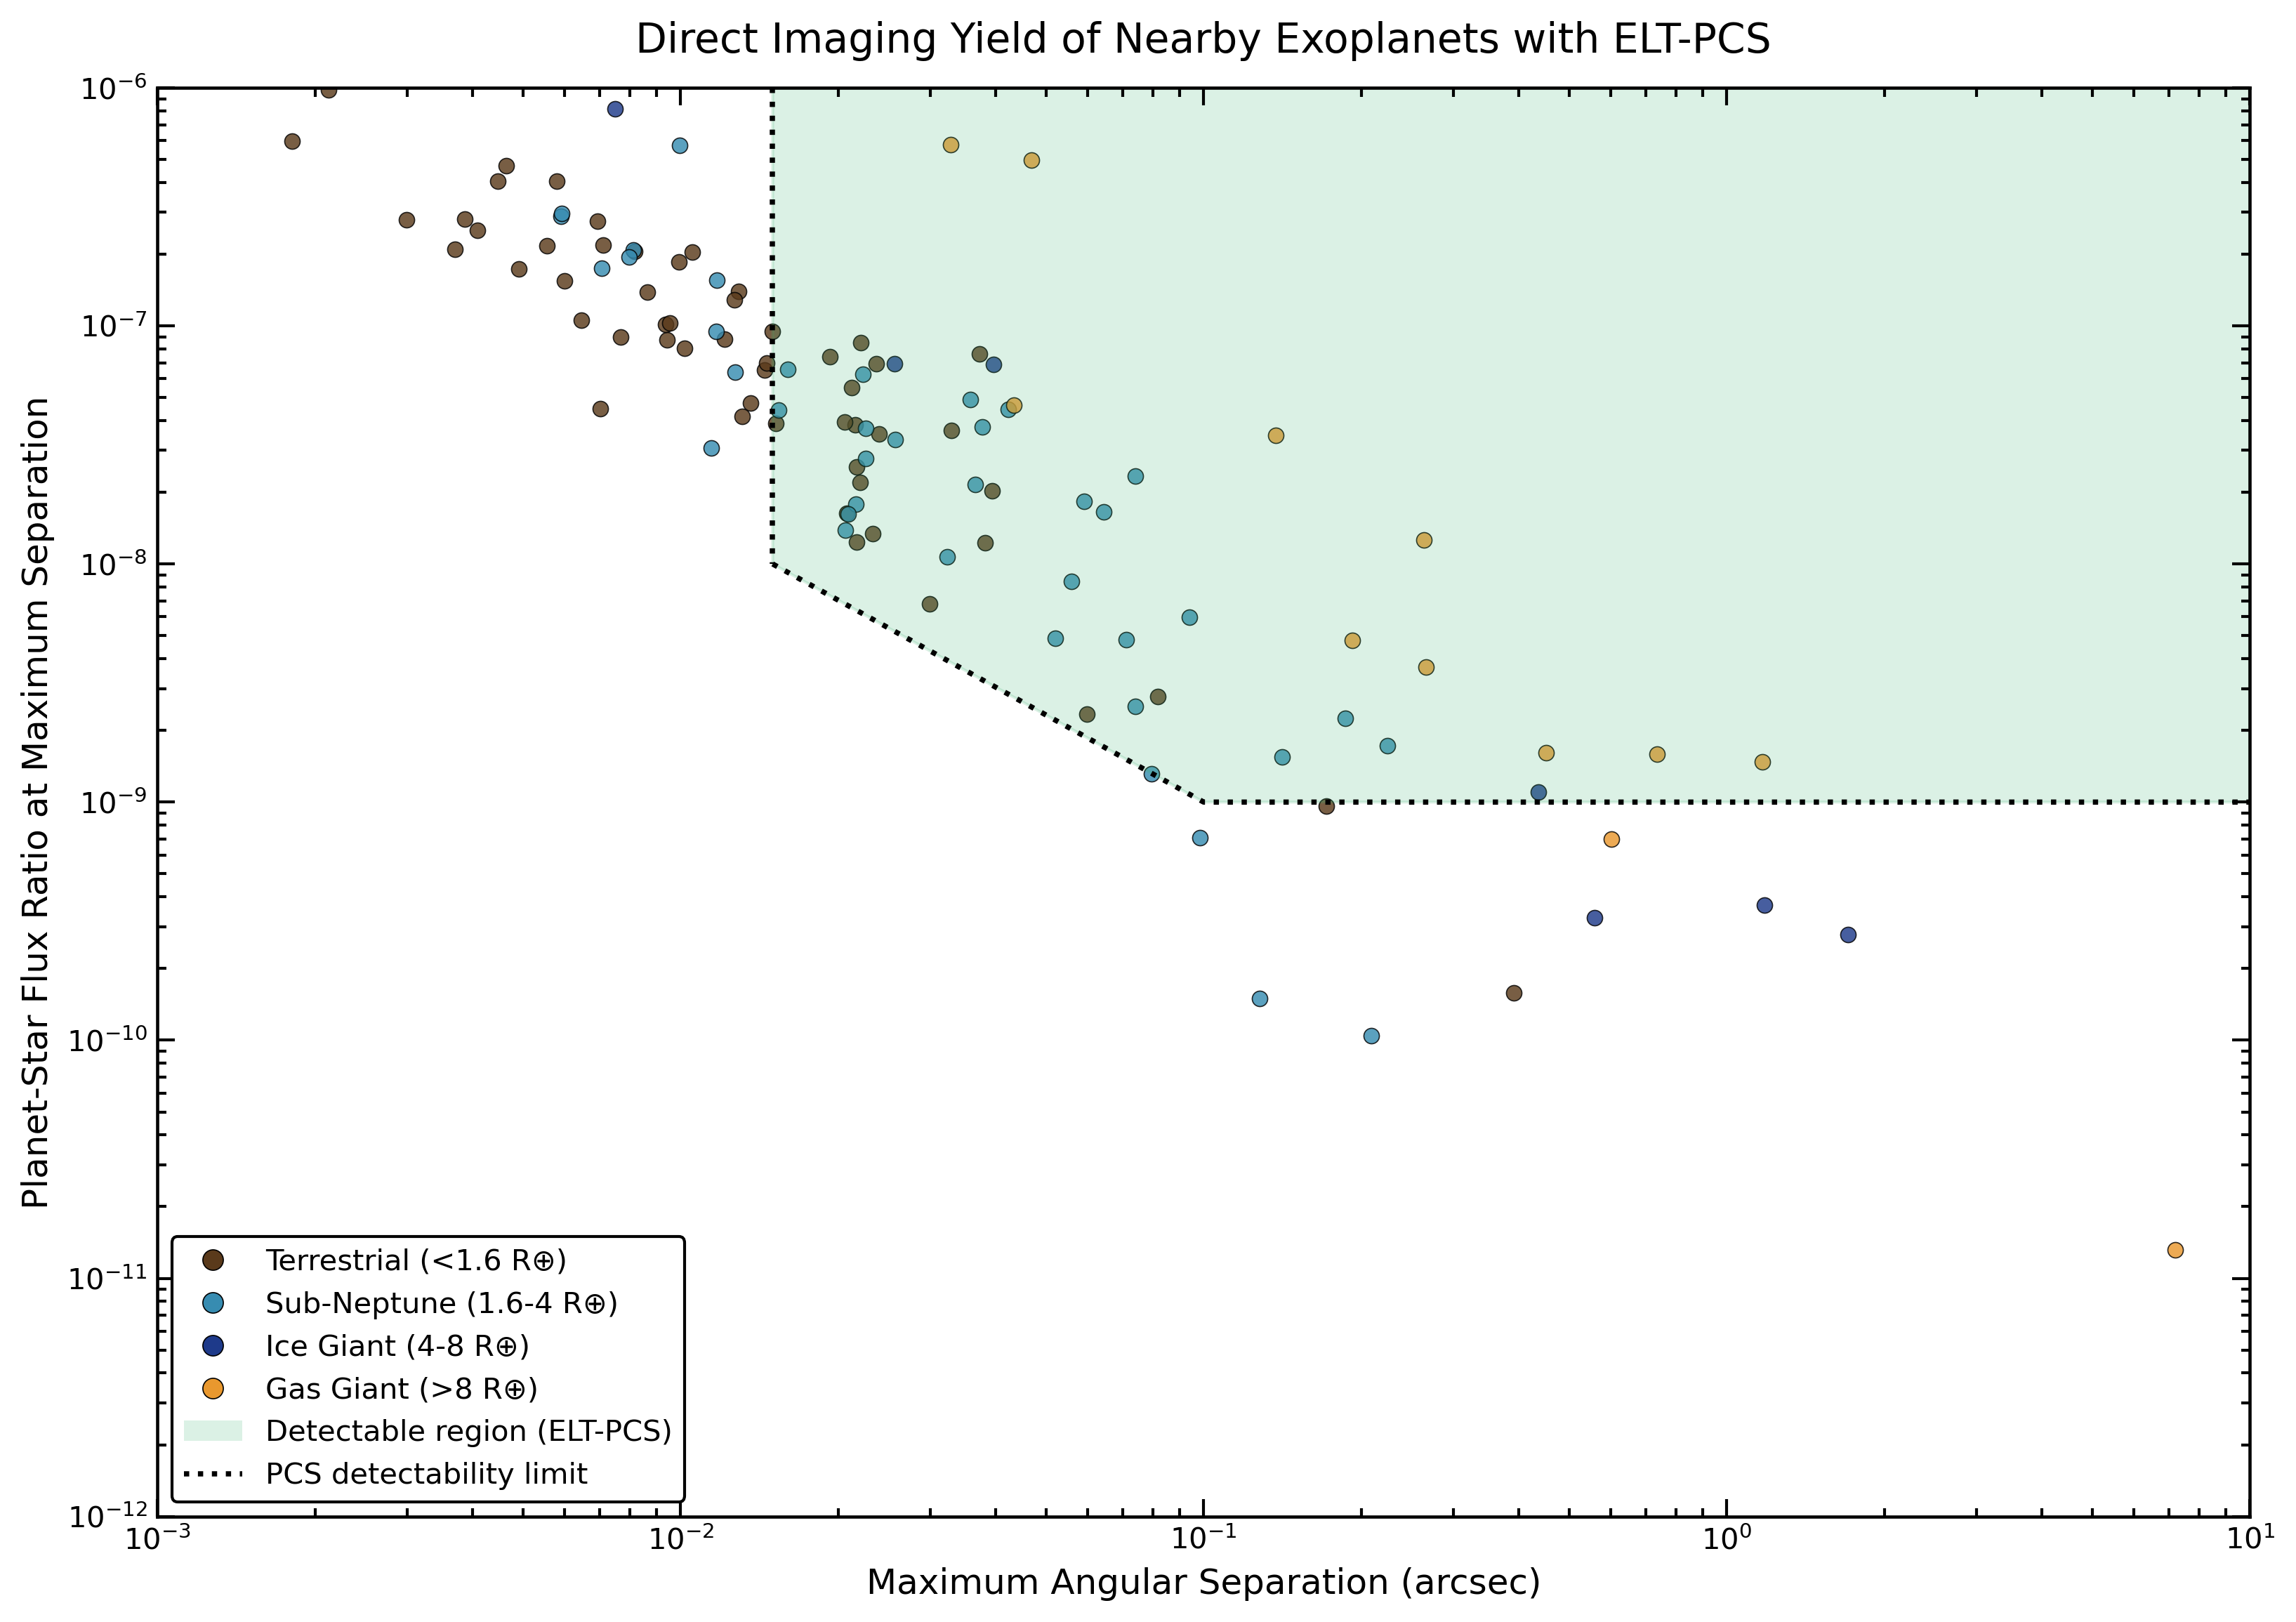

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Publication-style static figure based on the same data as the interactive plot.
# No interactivity, no hover, suitable for article export.

fig_pub, ax = plt.subplots(figsize=(11, 7.8), dpi=300)

# Category scatter points with the same colors used in the interactive figure.
for category, color in color_map.items():
    subset = plot_df[plot_df['radius_category'] == category]
    if subset.empty:
        continue
    ax.scatter(
        subset['max_sep_arcsec'],
        subset['contrast_at_max_sep'],
        s=28,
        c=color,
        edgecolors='black',
        linewidths=0.4,
        alpha=0.82
    )

# Detectability region and boundary.
ax.fill(
    np.concatenate([x_limit, [10, PCS_IWA_ARCSEC]]),
    np.concatenate([y_limit, [1e-6, 1e-6]]),
    color='mediumseagreen',
    alpha=0.18
 )
ax.plot(
    x_limit,
    y_limit,
    color='black',
    linestyle=':',
    linewidth=1.8
 )
ax.plot(
    [PCS_IWA_ARCSEC, PCS_IWA_ARCSEC],
    [1e-6, DETECT_Y_AT_IWA],
    color='black',
    linestyle=':',
    linewidth=1.8
 )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-3, 1e1)
ax.set_ylim(1e-12, 1e-6)

# Ticks formatted as 10^-x rather than 1e-x.
def ten_power_formatter(value, position):
    if position is None or value <= 0:
        return ''
    exponent = int(round(np.log10(value)))
    return rf'$10^{{{exponent}}}$'

ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=7))
ax.xaxis.set_major_formatter(FuncFormatter(ten_power_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(ten_power_formatter))

# Clean publication styling with a closed box.
ax.tick_params(which='both', direction='in', top=True, right=True, length=6, width=1.0)
ax.tick_params(which='minor', length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color('black')

ax.set_xlabel('Maximum Angular Separation (arcsec)', fontsize=12)
ax.set_ylabel('Planet-Star Flux Ratio at Maximum Separation', fontsize=12)
ax.set_title('Direct Imaging Yield of Nearby Exoplanets with ELT-PCS', fontsize=14, pad=12)

# Explicit handles so the legend is stable and publication-ready.
category_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color_map[name], markeredgecolor='black', markeredgewidth=0.4, markersize=7, label=name)
    for name in color_map.keys()
 ]
region_handle = Patch(facecolor='mediumseagreen', edgecolor='none', alpha=0.18, label='Detectable region (ELT-PCS)')
boundary_handle = Line2D([0], [0], color='black', linestyle=':', linewidth=1.8, label='PCS detectability limit')

ax.legend(
    handles=category_handles + [region_handle, boundary_handle],
    title='',
    loc='lower left',
    frameon=True,
    framealpha=1.0,
    edgecolor='black',
    fontsize=10
 )

fig_pub.tight_layout()
plt.show()
# Optional export for publication.
fig_pub.savefig('exoplanets_publication_figure.png', dpi=600, bbox_inches='tight')

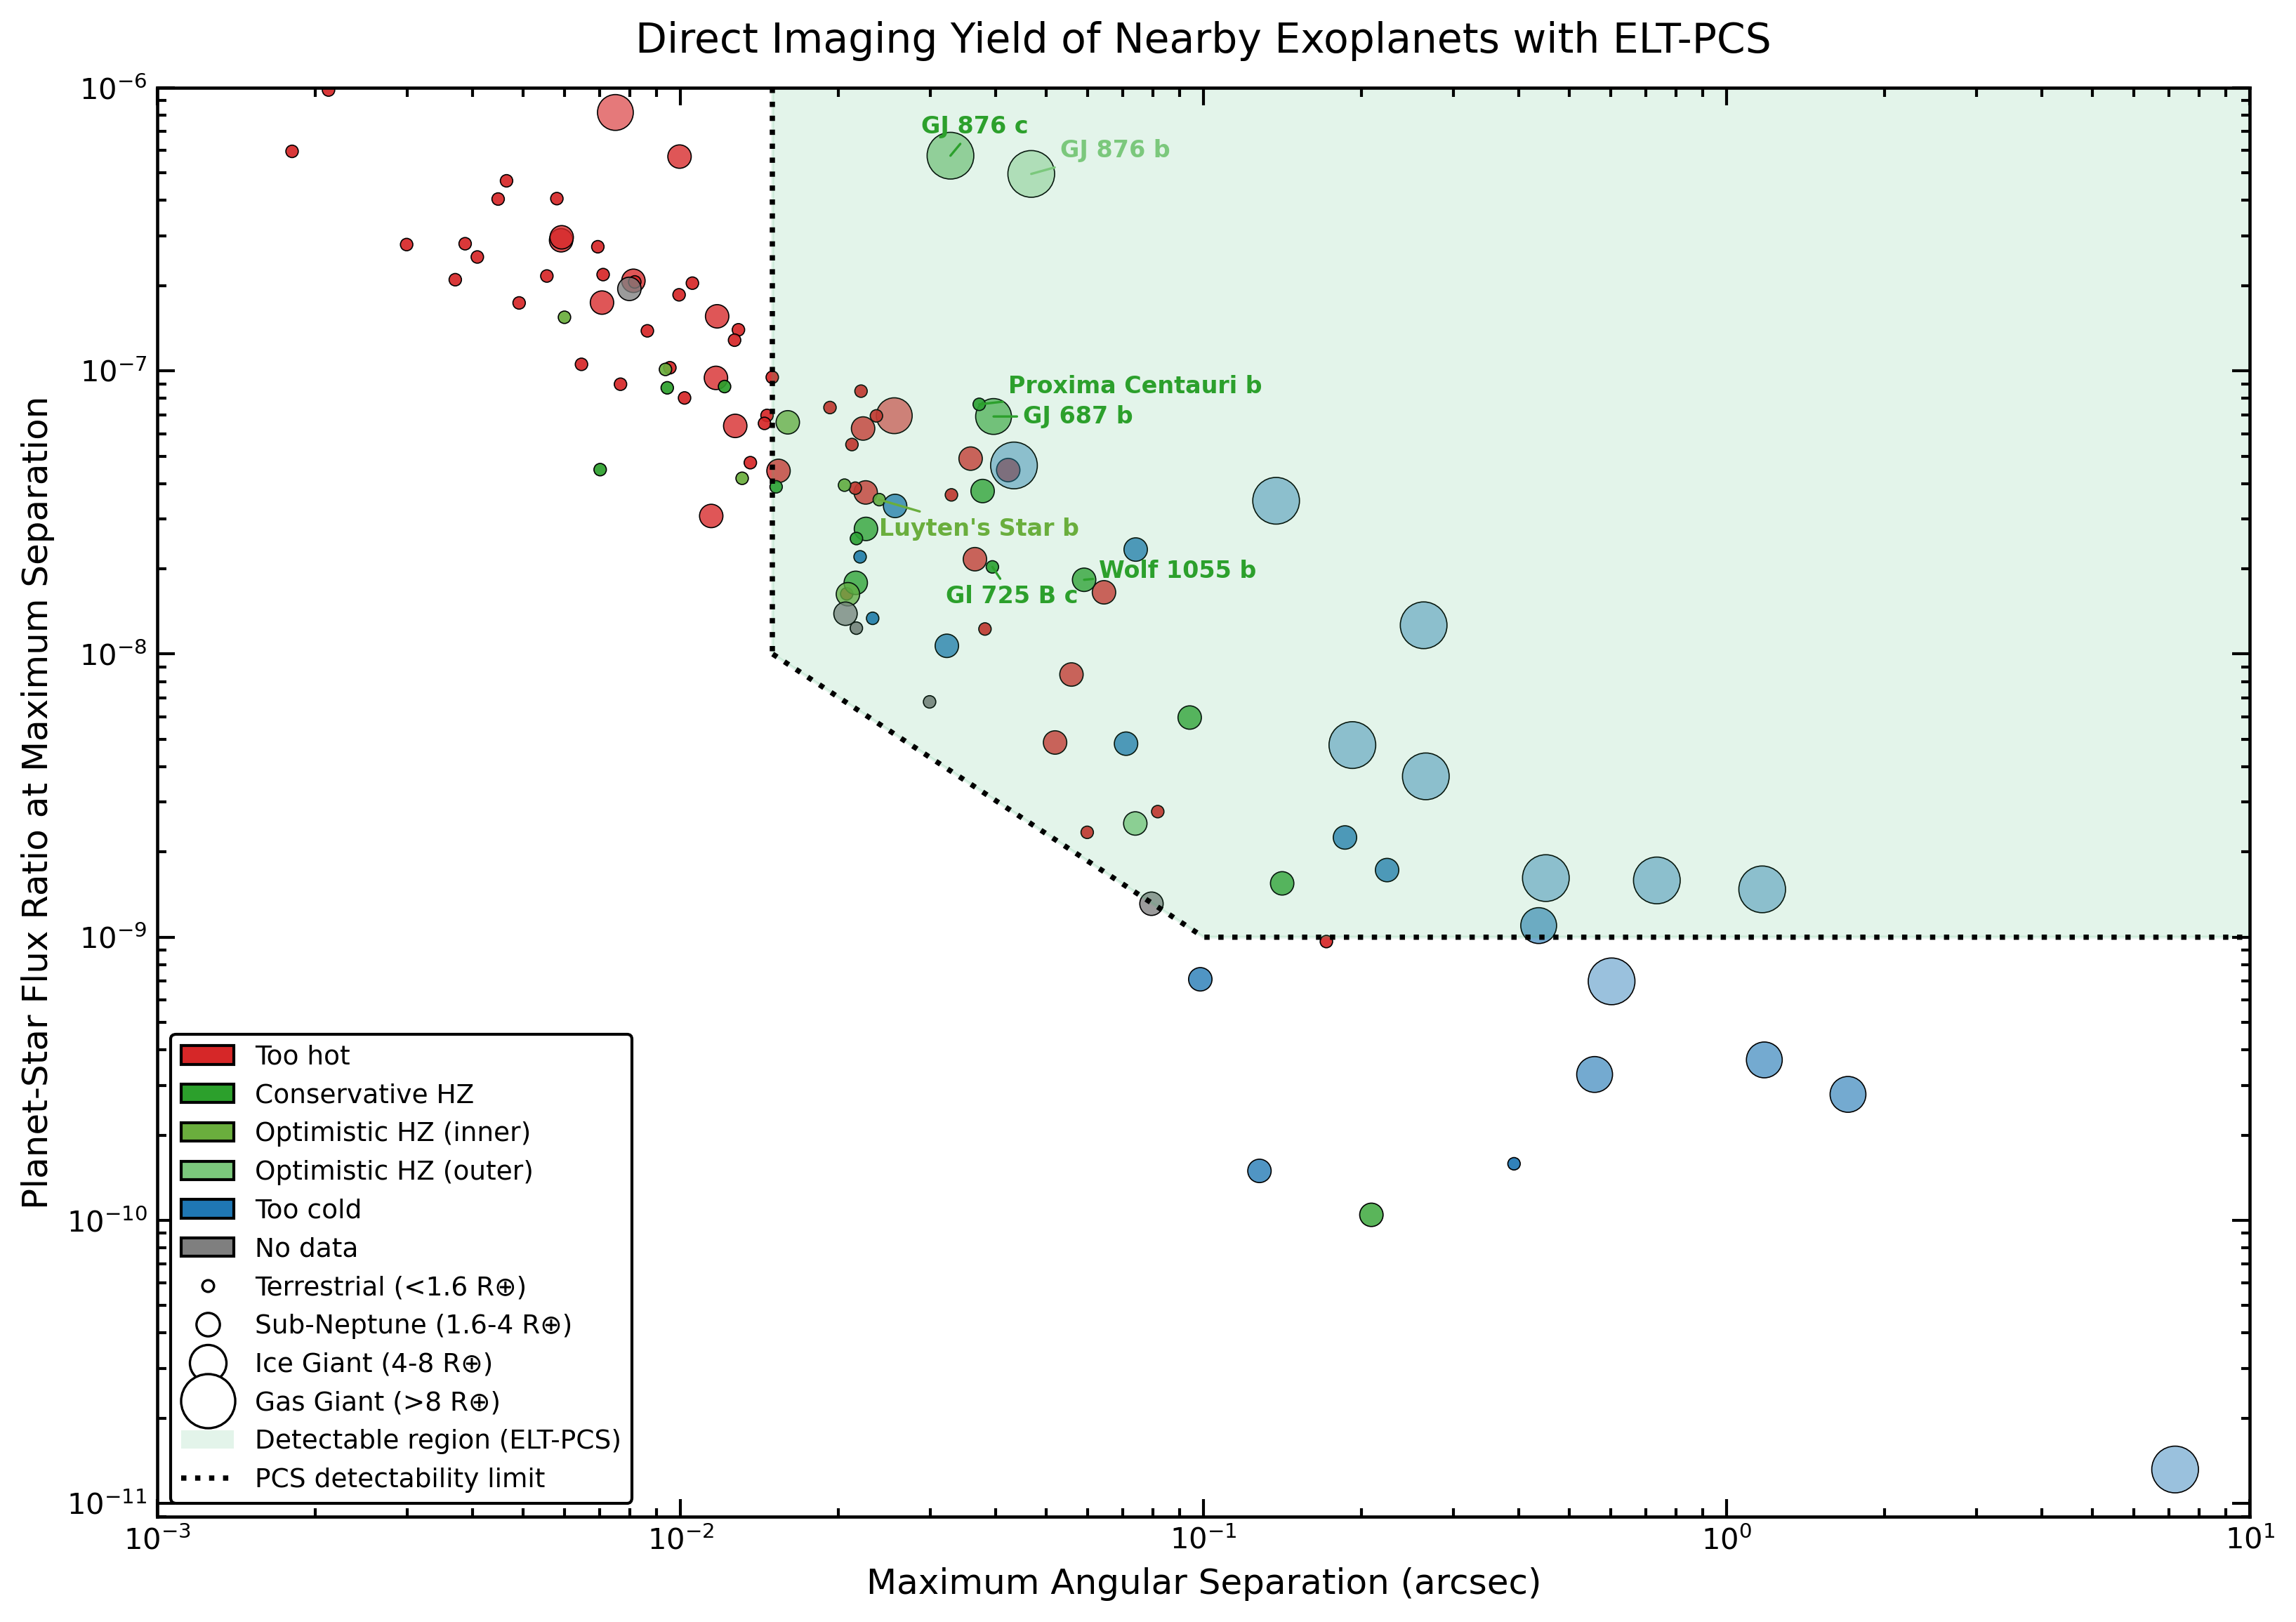

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, LogLocator

# Alternative publication-style figure for design testing.
# Same data and detectability boundary, but colors encode habitability status
# and point sizes encode planet class.

fig_test, ax = plt.subplots(figsize=(11, 7.8), dpi=300)

size_map = {
    'Terrestrial (<1.6 R⊕)': 18,
    'Sub-Neptune (1.6-4 R⊕)': 64,
    'Ice Giant (4-8 R⊕)': 150,
    'Gas Giant (>8 R⊕)': 255,
}

alpha_map = {
    'Terrestrial (<1.6 R⊕)': 0.92,
    'Sub-Neptune (1.6-4 R⊕)': 0.78,
    'Ice Giant (4-8 R⊕)': 0.62,
    'Gas Giant (>8 R⊕)': 0.45,
}

draw_order_map = {
    'Gas Giant (>8 R⊕)': 0,
    'Ice Giant (4-8 R⊕)': 1,
    'Sub-Neptune (1.6-4 R⊕)': 2,
    'Terrestrial (<1.6 R⊕)': 3,
}

habitability_color_map = {
    'Too hot': '#d62728',
    'Conservative HZ': '#2ca02c',
    'Optimistic HZ (inner)': '#6aae3d',
    'Optimistic HZ (outer)': '#7bc87c',
    'Too cold': '#1f77b4',
    'No data': '#7f7f7f',
}

plot_df_test = plot_df.copy()
plot_df_test['point_size'] = plot_df_test['radius_category'].map(size_map).fillna(34)
plot_df_test['point_alpha'] = plot_df_test['radius_category'].map(alpha_map).fillna(0.75)
plot_df_test['draw_order'] = plot_df_test['radius_category'].map(draw_order_map).fillna(99)
plot_df_test['habitability_color'] = plot_df_test['hz_zone_clean'].map(habitability_color_map).fillna(habitability_color_map['No data'])

for hz_label, color in habitability_color_map.items():
    subset_hz = plot_df_test[plot_df_test['hz_zone_clean'].eq(hz_label)].sort_values('draw_order')
    if subset_hz.empty:
        continue
    rgba_colors = [
        mcolors.to_rgba(color, alpha=float(alpha_value))
        for alpha_value in subset_hz['point_alpha'].to_numpy()
    ]
    ax.scatter(
        subset_hz['max_sep_arcsec'],
        subset_hz['contrast_at_max_sep'],
        s=subset_hz['point_size'],
        c=rgba_colors,
        edgecolors='black',
        linewidths=0.4,
        label=hz_label,
    )

# Label a few relevant systems directly on the plot.
target_planets = [
    'Proxima Centauri b',
    'GJ 876 b',
    'GJ 876 c',
    "Luyten's star b",
    'Gl 725 B c',
    'Wolf 1055 b',
    'GJ 687 b',
]
label_offsets = {
    'Proxima Centauri b': (10, 6),
    'GJ 876 b': (10, 8),
    'GJ 876 c': (-10, 10),
    "Luyten's star b": (0, -10),
    'Gl 725 B c': (-16, -10),
    'Wolf 1055 b': (5, 3),
    'GJ 687 b': (10, 0),
}

for target_name in target_planets:
    target_rows = plot_df_test[plot_df_test['planet_label'].str.contains(target_name, case=False, na=False)]
    if target_rows.empty:
        continue
    for _, target_row in target_rows.iterrows():
        label_color = target_row['habitability_color'] if pd.notna(target_row['habitability_color']) else 'black'
        dx, dy = label_offsets.get(target_name, (8, 6))
        ax.annotate(
            target_row['planet_label'],
            xy=(target_row['max_sep_arcsec'], target_row['contrast_at_max_sep']),
            xytext=(dx, dy),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=8,
            color=label_color,
            fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=label_color, linewidth=0.8, shrinkA=0, shrinkB=0),
        )

# Keep the same detectability region and boundary as the main figure.
ax.fill(
    np.concatenate([x_limit, [10, PCS_IWA_ARCSEC]]),
    np.concatenate([y_limit, [1e-6, 1e-6]]),
    color='mediumseagreen',
    alpha=0.14
 )
ax.plot(
    x_limit,
    y_limit,
    color='black',
    linestyle=':',
    linewidth=1.8
 )
ax.plot(
    [PCS_IWA_ARCSEC, PCS_IWA_ARCSEC],
    [1e-6, DETECT_Y_AT_IWA],
    color='black',
    linestyle=':',
    linewidth=1.8
 )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1e-3, 1e1)
ax.set_ylim(9e-12, 1e-6)

def ten_power_formatter(value, position):
    if position is None or value <= 0:
        return ''
    exponent = int(round(np.log10(value)))
    return rf'$10^{{{exponent}}}$'

ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=5))
ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=7))
ax.xaxis.set_major_formatter(FuncFormatter(ten_power_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(ten_power_formatter))

ax.tick_params(which='both', direction='in', top=True, right=True, length=6, width=1.0)
ax.tick_params(which='minor', length=3)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.1)
    spine.set_color('black')

ax.set_xlabel('Maximum Angular Separation (arcsec)', fontsize=12)
ax.set_ylabel('Planet-Star Flux Ratio at Maximum Separation', fontsize=12)
ax.set_title('Direct Imaging Yield of Nearby Exoplanets with ELT-PCS', fontsize=14, pad=12)

size_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white', markeredgecolor='black', markeredgewidth=0.8, markersize=4.0, label='Terrestrial (<1.6 R⊕)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white', markeredgecolor='black', markeredgewidth=0.8, markersize=8.0, label='Sub-Neptune (1.6-4 R⊕)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white', markeredgecolor='black', markeredgewidth=0.8, markersize=12.5, label='Ice Giant (4-8 R⊕)'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='white', markeredgecolor='black', markeredgewidth=0.8, markersize=18.5, label='Gas Giant (>8 R⊕)'),
]

habitability_handles = [
    Patch(facecolor=habitability_color_map['Too hot'], edgecolor='black', label='Too hot'),
    Patch(facecolor=habitability_color_map['Conservative HZ'], edgecolor='black', label='Conservative HZ'),
    Patch(facecolor=habitability_color_map['Optimistic HZ (inner)'], edgecolor='black', label='Optimistic HZ (inner)'),
    Patch(facecolor=habitability_color_map['Optimistic HZ (outer)'], edgecolor='black', label='Optimistic HZ (outer)'),
    Patch(facecolor=habitability_color_map['Too cold'], edgecolor='black', label='Too cold'),
    Patch(facecolor=habitability_color_map['No data'], edgecolor='black', label='No data'),
]

region_handle = Patch(facecolor='mediumseagreen', edgecolor='none', alpha=0.14, label='Detectable region (ELT-PCS)')
boundary_handle = Line2D([0], [0], color='black', linestyle=':', linewidth=1.8, label='PCS detectability limit')

ax.legend(
    handles=habitability_handles + size_handles + [region_handle, boundary_handle],
    title='',
    loc='lower left',
    frameon=True,
    framealpha=1.0,
    edgecolor='black',
    fontsize=9
 )

fig_test.tight_layout()
plt.show()

## Final Catalogue QA Summary

This final check reports coverage and missing-data rates for key columns used in the detectability analysis, helping document dataset quality in the publication workflow.

In [10]:
from IPython.display import display

# Final data-quality summary focused on fields used by this notebook.

def coverage_pct(series):
    return 100.0 * float(series.notna().mean()) if len(series) else np.nan

name_candidates = ['name', 'planet_name', 'pl_name']
planet_name_col = next((c for c in name_candidates if c in df.columns), None)
planet_labels = df[planet_name_col].astype(str) if planet_name_col else df.index.astype(str)

mass_curated = df['mass_earth_th'].apply(to_float) if 'mass_earth_th' in df.columns else pd.Series(np.nan, index=df.index)
mass_primary = df['mass_earth'].apply(to_float) if 'mass_earth' in df.columns else pd.Series(np.nan, index=df.index)
mass_fallback = df['mass_sini_earth'].apply(to_float) if 'mass_sini_earth' in df.columns else pd.Series(np.nan, index=df.index)
mass_used = mass_curated.where(mass_curated.notna(), mass_primary.where(mass_primary.notna(), mass_fallback))

radius_curated = df['radius_earth_th'].apply(to_float) if 'radius_earth_th' in df.columns else pd.Series(np.nan, index=df.index)
radius_legacy = df['radius_earth_hz'].apply(to_float) if 'radius_earth_hz' in df.columns else pd.Series(np.nan, index=df.index)
radius_used = radius_curated.where(radius_curated.notna(), radius_legacy)

distance_used = df[DISTANCE_COLUMN].apply(to_float) if DISTANCE_COLUMN in df.columns else pd.Series(np.nan, index=df.index)
hz_used = df['hz_zone_clean'] if 'hz_zone_clean' in df.columns else pd.Series(['No data'] * len(df), index=df.index)

qa_summary = pd.DataFrame({
    'metric': [
        'Rows in filtered sample',
        'Mass coverage (mass_earth_th primary, legacy fallback)',
        'Radius coverage (radius_earth_th primary, legacy fallback)',
        f'Distance coverage ({DISTANCE_COLUMN})',
        'Planets plotted (valid radius + separation + contrast)'
    ],
    'value': [
        len(df),
        f"{coverage_pct(mass_used):.1f}%",
        f"{coverage_pct(radius_used):.1f}%",
        f"{coverage_pct(distance_used):.1f}%",
        int(len(plot_df))
    ]
})

planet_qa = pd.DataFrame({
    'planet': planet_labels,
    'mass_earth_used': mass_used,
    'radius_earth_used': radius_used,
    DISTANCE_COLUMN: distance_used,
    'hz_zone': hz_used
})

print('Final QA summary for publication:')
display(qa_summary)

print('\nFirst 20 rows of per-planet QA table:')
display(planet_qa.head(20))

print('\nHZ zone distribution:')
display(hz_used.value_counts(dropna=False).rename_axis('hz_zone').reset_index(name='count'))

Final QA summary for publication:


,metric,value
0,Rows in filtered sample,123
1,"Mass coverage (mass_earth_th primary, legacy f...",100.0%
2,"Radius coverage (radius_earth_th primary, lega...",100.0%
3,Distance coverage (star_distance),100.0%
4,Planets plotted (valid radius + separation + c...,120



First 20 rows of per-planet QA table:


,planet,mass_earth_used,radius_earth_used,star_distance,hz_zone
0,61 Vir b,5.784477,2.009595,8.534418,Too hot
1,61 Vir c,17.839708,4.355004,8.534418,Too hot
2,61 Vir d,10.920584,3.076213,8.534418,Too hot
3,82 Eri b,2.148520,1.290367,6.041413,Too hot
4,82 Eri c,2.981230,1.439235,6.041413,Too hot
5,82 Eri d,5.816260,2.016987,6.041413,Conservative HZ
7,AU Mic b,8.991366,4.786235,9.714095,Too hot
8,AU Mic c,14.461193,2.791036,9.714095,Too hot
9,AU Mic d,1.052012,1.017045,9.714095,No data
10,Barnard's star b,0.299077,0.668745,1.828234,Too hot



HZ zone distribution:


,hz_zone,count
0,Too hot,65
1,Too cold,25
2,Conservative HZ,16
3,No data,8
4,Optimistic HZ (inner),7
5,Optimistic HZ (outer),2


In [11]:
# Interactive Plotly figure with style aligned to the alternative publication plot:
# - Color encodes habitability zone (HZ)
# - Marker size encodes planet type (radius-based category)

hz_color_map = {
    'Too hot': '#d62728',
    'Conservative HZ': '#2ca02c',
    'Optimistic HZ (inner)': '#6aae3d',
    'Optimistic HZ (outer)': '#7bc87c',
    'Too cold': '#1f77b4',
    'No data': '#7f7f7f',
}

size_by_type_map = {
    CATEGORY_LABEL['Terrestrial']: 2,
    CATEGORY_LABEL['Sub-Neptune']: 4,
    CATEGORY_LABEL['Ice Giant']: 8,
    CATEGORY_LABEL['Gas Giant']: 14,
}

# Per-planet opacity: make larger planets more transparent.
opacity_by_type_map = {
    CATEGORY_LABEL['Terrestrial']: 0.95,
    CATEGORY_LABEL['Sub-Neptune']: 0.75,
    CATEGORY_LABEL['Ice Giant']: 0.55,
    CATEGORY_LABEL['Gas Giant']: 0.45,
}

hz_order = [
    'Too hot',
    'Conservative HZ',
    'Optimistic HZ (inner)',
    'Optimistic HZ (outer)',
    'Too cold',
    'No data',
]

plot_df_hz = plot_df.copy()
plot_df_hz['hz_zone_clean'] = plot_df_hz['hz_zone_clean'].fillna('No data').astype(str).str.strip()
plot_df_hz.loc[plot_df_hz['hz_zone_clean'].eq(''), 'hz_zone_clean'] = 'No data'
plot_df_hz['point_size_hz'] = plot_df_hz['radius_category'].map(size_by_type_map).fillna(34)
plot_df_hz['point_opacity_hz'] = plot_df_hz['radius_category'].map(opacity_by_type_map).fillna(0.75)

fig_hz = px.scatter(
    plot_df_hz,
    x='max_sep_arcsec',
    y='contrast_at_max_sep',
    color='hz_zone_clean',
    color_discrete_map=hz_color_map,
    category_orders={'hz_zone_clean': hz_order},
    size='point_size_hz',
    size_max=max(size_by_type_map.values()),
    hover_name='planet_label',
    custom_data=[
        'status_hover_html',
        'type_hover_html',
        'hz_hover_html',
        'mass_earth_used',
        'radius_earth_used',
        DISTANCE_COLUMN,
        'point_opacity_hz',
    ],
    labels={
        'max_sep_arcsec': 'Maximum Angular Separation [arcsec]',
        'contrast_at_max_sep': 'Flux Ratio (Contrast) at Maximum Separation',
        'hz_zone_clean': 'HZ Zone',
    },
    title='Direct Imaging Yield of Nearby Exoplanets with ELT-PCS (Colored by Habitability Zone)',
)

fig_hz.update_traces(
    marker=dict(line=dict(width=1, color='black')),
    hovertemplate=(
        "<b>%{hovertext}</b><br>"
        "Status: %{customdata[0]}<br>"
        "Planet type: %{customdata[1]}<br>"
        "HZ zone: %{customdata[2]}<br>"
        "Mass [M⊕]: %{customdata[3]:.3f}<br>"
        "Radius [R⊕]: %{customdata[4]:.3f}<br>"
        "Distance [pc]: %{customdata[5]:.3f}<extra></extra>"
    ),
)

# Apply per-point opacity so Ice Giants and Gas Giants are more transparent.
for trace in fig_hz.data:
    if hasattr(trace, 'customdata') and trace.customdata is not None:
        trace.marker.opacity = [float(row[6]) for row in trace.customdata]

# Detectability region and boundary (same model used in the main interactive figure).
fig_hz.add_scatter(
    x=np.concatenate([x_limit, [10, PCS_IWA_ARCSEC]]),
    y=np.concatenate([y_limit, [1e-6, 1e-6]]),
    mode='lines',
    line=dict(width=0),
    fill='toself',
    fillcolor='rgba(60, 179, 113, 0.14)',
    name='ELT-PCS Detectable Region',
    hoverinfo='skip',
)

fig_hz.add_scatter(
    x=[PCS_IWA_ARCSEC, PCS_IWA_ARCSEC],
    y=[1e-6, DETECT_Y_AT_IWA],
    mode='lines',
    line=dict(color='black', width=2, dash='dot'),
    showlegend=False,
    hoverinfo='skip',
)

fig_hz.add_scatter(
    x=x_limit,
    y=y_limit,
    mode='lines',
    line=dict(color='black', width=2, dash='dot'),
    name='PCS Detectability Limit',
)

fig_hz.update_xaxes(
    type='log',
    autorange=False,
    range=[-3, 1],
    dtick=1,
    tickformat='.0e',
    showgrid=True,
    gridcolor='rgba(120, 120, 120, 0.35)',
    griddash='dash',
    minor=dict(showgrid=True, dtick='D1', gridcolor='rgba(160, 160, 160, 0.22)', griddash='dot'),
)

fig_hz.update_yaxes(
    type='log',
    autorange=False,
    range=[-12, -6],
    dtick=1,
    tickformat='.0e',
    showgrid=True,
    gridcolor='rgba(120, 120, 120, 0.35)',
    griddash='dash',
    minor=dict(showgrid=True, dtick='D1', gridcolor='rgba(160, 160, 160, 0.22)', griddash='dot'),
)

fig_hz.update_layout(
    template='plotly_white',
    plot_bgcolor='white',
    legend_title_text='',
    width=1100,
    height=780,
    hoverlabel=dict(bgcolor='black', bordercolor='black', font=dict(color='white')),
)

fig_hz.show()

# Export the HZ-styled interactive figure to HTML.
OUTPUT_HZ_INTERACTIVE_HTML = Path('exoplanets_visualization_hz.html')

if 'fig_hz' not in globals():
    raise NameError("'fig_hz' was not found. Run cell 20 first to build the figure.")

fig_hz.write_html(
    OUTPUT_HZ_INTERACTIVE_HTML,
    include_plotlyjs=True,
    full_html=True,
)

print(f"Interactive HZ figure exported to: {OUTPUT_HZ_INTERACTIVE_HTML}")

In [12]:
# Experimental export: standalone HTML with planet search controls (isolate/highlight/reset).
import plotly.graph_objects as go

OUTPUT_HZ_SEARCHABLE_HTML = Path('exoplanets_visibility.html')
SEARCHABLE_HTML_TITLE = 'Direct Imaging Yield of Nearby Exoplanets with ELT-PCS (Colored by Habitability Zone)'

if 'fig_hz' not in globals():
    raise NameError("'fig_hz' was not found. Run cell 20 first to build the figure.")

# Work on a copy so the base figure used in the notebook remains unchanged.
fig_hz_search = go.Figure(fig_hz)
fig_hz_search.update_layout(
    title_text='',
    margin=dict(t=18),
    legend_title_text='<b>Interactive legend</b>',
)
fig_hz_search.add_scatter(
    x=[],
    y=[],
    mode='markers+text',
    marker=dict(symbol='star', size=22, color='yellow', line=dict(color='black', width=1.5)),
    text=[],
    textposition='top center',
    name='Search highlight',
    showlegend=False,
    hoverinfo='skip',
)

plot_div_html = fig_hz_search.to_html(
    include_plotlyjs='cdn',
    full_html=False,
    div_id='hz_plot_div',
)

html_with_search = f"""<!doctype html>
<html lang='en'>
<head>
  <meta charset='utf-8' />
  <meta name='viewport' content='width=device-width, initial-scale=1' />
  <title>ELT-PCS HZ Interactive Search</title>
  <style>
    :root {{
      --bg: #f6f8fa;
      --panel: #ffffff;
      --text: #111827;
      --muted: #6b7280;
      --border: #d1d5db;
      --focus: #0f766e;
      --button: #111827;
      --button-text: #ffffff;
    }}
    body {{
      margin: 0;
      font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
      background: var(--bg);
      color: var(--text);
    }}
    .wrap {{
      max-width: 1200px;
      margin: 1.2rem auto;
      padding: 0 1rem;
    }}
    .top-panel {{
      padding: 0.9rem;
      background: var(--panel);
      border: 1px solid var(--border);
      border-radius: 10px;
      margin-bottom: 0.9rem;
    }}
    .page-title {{
      margin: 0 0 0.75rem 0;
      font-size: 1.12rem;
      font-weight: 700;
      line-height: 1.3;
      color: var(--text);
    }}
    .controls {{
      display: flex;
      flex-wrap: wrap;
      gap: 0.6rem;
      align-items: center;
    }}
    .controls input {{
      flex: 1 1 320px;
      min-width: 240px;
      font-size: 0.95rem;
      padding: 0.55rem 0.7rem;
      border: 1px solid var(--border);
      border-radius: 8px;
      outline: none;
    }}
    .controls input:focus {{
      border-color: var(--focus);
      box-shadow: 0 0 0 3px rgba(15, 118, 110, 0.15);
    }}
    .controls button {{
      border: 0;
      border-radius: 8px;
      padding: 0.52rem 0.82rem;
      cursor: pointer;
      background: var(--button);
      color: var(--button-text);
      font-size: 0.9rem;
    }}
    .status {{
      font-size: 0.9rem;
      color: var(--muted);
      margin-left: 0.2rem;
    }}
    .plot-panel {{
      background: var(--panel);
      border: 1px solid var(--border);
      border-radius: 10px;
      padding: 0.15rem 0.5rem 0.5rem 0.5rem;
    }}
  </style>
</head>
<body>
  <div class='wrap'>
    <div class='top-panel'>
      <h1 class='page-title'>{SEARCHABLE_HTML_TITLE}</h1>
      <div class='controls'>
        <input id='planetSearchInput' type='text' placeholder='Search planet (example: Proxima, GJ 876 b, etc.)' />
        <button id='isolateBtn'>Isolate</button>
        <button id='highlightBtn'>Highlight</button>
        <button id='resetBtn'>Reset</button>
        <span id='searchStatus' class='status'>Type a name and click a mode.</span>
      </div>
    </div>
    <div class='plot-panel'>
      {plot_div_html}
    </div>
  </div>

  <script>
    (function () {{
      const gd = document.getElementById('hz_plot_div');
      const input = document.getElementById('planetSearchInput');
      const status = document.getElementById('searchStatus');
      const isolateBtn = document.getElementById('isolateBtn');
      const highlightBtn = document.getElementById('highlightBtn');
      const resetBtn = document.getElementById('resetBtn');

      let baseOpacity = [];
      let baseSize = [];
      let highlightTraceIndex = null;

      function asArray(value, n, fallback) {{
        if (Array.isArray(value)) return value.slice();
        if (typeof value === 'number') return Array(n).fill(value);
        return Array(n).fill(fallback);
      }}

      function ensureBase() {{
        if (!gd || !gd.data || gd.data.length === 0) return false;
        if (highlightTraceIndex !== null) return true;

        highlightTraceIndex = gd.data.length - 1;
        baseOpacity = gd.data.map((trace) => {{
          const n = (trace.x || []).length;
          const marker = trace.marker || {{}};
          return asArray(marker.opacity, n, 0.75);
        }});
        baseSize = gd.data.map((trace) => {{
          const n = (trace.x || []).length;
          const marker = trace.marker || {{}};
          return asArray(marker.size, n, 8);
        }});
        return true;
      }}

      function findMatches(query) {{
        const q = (query || '').trim().toLowerCase();
        if (!q) return [];
        const matches = [];

        gd.data.forEach((trace, traceIdx) => {{
          if (traceIdx === highlightTraceIndex) return;
          const xArr = trace.x || [];
          const yArr = trace.y || [];
          const hover = trace.hovertext;

          for (let i = 0; i < xArr.length; i++) {{
            const rawName = Array.isArray(hover) ? hover[i] : hover;
            const name = String(rawName || '');
            if (name.toLowerCase().includes(q)) {{
              matches.push({{
                traceIdx,
                pointIdx: i,
                x: xArr[i],
                y: yArr[i],
                name
              }});
            }}
          }}
        }});

        return matches;
      }}

      function applySearch(isolateMode) {{
        if (!ensureBase()) return;
        const query = input.value;
        const matches = findMatches(query);

        if (!query.trim()) {{
          status.textContent = 'Write a planet name first.';
          return;
        }}

        if (!matches.length) {{
          status.textContent = `No matches found for: ${{query}}`;
          return;
        }}

        const matchedByTrace = new Map();
        matches.forEach((m) => {{
          if (!matchedByTrace.has(m.traceIdx)) matchedByTrace.set(m.traceIdx, new Set());
          matchedByTrace.get(m.traceIdx).add(m.pointIdx);
        }});

        gd.data.forEach((trace, tIdx) => {{
          if (tIdx === highlightTraceIndex) return;

          const op = baseOpacity[tIdx].slice();
          const sz = baseSize[tIdx].slice();
          const matchedSet = matchedByTrace.get(tIdx) || new Set();

          for (let i = 0; i < op.length; i++) {{
            if (matchedSet.has(i)) {{
              op[i] = 1.0;
              sz[i] = Math.max(10, Number(sz[i]) * 1.8);
            }} else if (isolateMode) {{
              op[i] = 0.06;
            }}
          }}

          Plotly.restyle(gd, {{ 'marker.opacity': [op], 'marker.size': [sz] }}, [tIdx]);
        }});

        const hx = matches.map((m) => m.x);
        const hy = matches.map((m) => m.y);
        const htext = matches.map((m) => m.name);

        Plotly.restyle(
          gd,
          {{
            x: [hx],
            y: [hy],
            text: [htext]
          }},
          [highlightTraceIndex]
        );

        status.textContent = `${{matches.length}} match(es) for "${{query}}"${{isolateMode ? ' (isolated)' : ' (highlighted)'}}.`;
      }}

      function resetPlot() {{
        if (!ensureBase()) return;

        gd.data.forEach((trace, tIdx) => {{
          if (tIdx === highlightTraceIndex) return;
          Plotly.restyle(
            gd,
            {{ 'marker.opacity': [baseOpacity[tIdx].slice()], 'marker.size': [baseSize[tIdx].slice()] }},
            [tIdx]
          );
        }});

        Plotly.restyle(gd, {{ x: [[]], y: [[]], text: [[]] }}, [highlightTraceIndex]);
        status.textContent = 'Plot reset. You can run a new search.';
      }}

      isolateBtn.addEventListener('click', () => applySearch(true));
      highlightBtn.addEventListener('click', () => applySearch(false));
      resetBtn.addEventListener('click', resetPlot);
      input.addEventListener('keydown', (event) => {{
        if (event.key === 'Enter') applySearch(false);
      }});

      if (gd) {{
        gd.on('plotly_afterplot', () => ensureBase());
        ensureBase();
      }}
    }})();
  </script>
</body>
</html>
"""

OUTPUT_HZ_SEARCHABLE_HTML.write_text(html_with_search, encoding='utf-8')
print(f"Searchable HTML exported to: {OUTPUT_HZ_SEARCHABLE_HTML}")

Searchable HTML exported to: exoplanets_visibility.html
